In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [91]:
# Advanced Analytics + Risk Metrics
nav = pd.read_csv("../data/raw/02_nav_history.csv")
fund = pd.read_csv("../data/raw/01_fund_master.csv")

In [92]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [93]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [94]:
nav['date'] = pd.to_datetime(nav['date']) # recognized as a date
nav['nav'] = pd.to_numeric(nav['nav']) #Makes sure NAV values are numeric.
nav = nav.dropna(subset=['amfi_code','date','nav']) #Removes rows where AMFI code, date, or NAV is missing.
nav = nav.sort_values(['amfi_code','date']) #Sorts each fund by date

In [95]:
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change() #Calculate daily returns

In [96]:
nav[['amfi_code', 'date', 'nav', 'daily_return']].head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [97]:
returns = nav.dropna(subset=['daily_return']).copy()

In [98]:
# Calculate VaR and CVaR
def calculate_var_cvar(group):
    var_threshold = group['daily_return'].quantile(0.05)

    # Returns below the VaR threshold
    cvar = group.loc[
        group['daily_return'] <= var_threshold,
        'daily_return'
    ].mean()

    return pd.Series({
        'VaR_95_pct': -var_threshold * 100,
        'CVaR_95_pct': -cvar * 100,
        'Observations': len(group)
    })


# Calculate for each fund
var_cvar = (
    returns.groupby('amfi_code')
    .apply(calculate_var_cvar)
    .reset_index()
)

# Add fund names
fund_names = (fund[['amfi_code', 'scheme_name']].drop_duplicates())
var_cvar = var_cvar.merge(fund_names,on='amfi_code',how='left')



C:\Users\amal\AppData\Local\Temp\ipykernel_11052\3185167088.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_var_cvar)


In [99]:
var_cvar.head()

,amfi_code,VaR_95_pct,CVaR_95_pct,Observations,scheme_name
0,100016,1.436364,1.806021,1149.0,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.379325,0.499376,1149.0,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.903354,2.345576,1149.0,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.328166,1.743943,1149.0,ABSL Frontline Equity Fund - Regular - Growth
4,101207,2.602125,3.245906,1149.0,ABSL Small Cap Fund - Regular - Growth


In [100]:
# Arrange the columns
var_cvar = var_cvar[
    [
        'amfi_code',
        'scheme_name',
        'VaR_95_pct',
        'CVaR_95_pct',
        'Observations'
    ]]

In [101]:
var_cvar = var_cvar.sort_values('VaR_95_pct',ascending=False) #sort by highest risk

In [102]:
var_cvar.to_csv('var_cvar_report.csv',index=False)

In [103]:
# Rolling 90-Day Sharpe Ratio

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

returns = returns.sort_values(['amfi_code', 'date']).copy() # Make sure data is sorted
print(returns[['amfi_code', 'date', 'daily_return']].head()) # Check the required columns


      amfi_code       date  daily_return
5751     100016 2022-01-04     -0.010306
5752     100016 2022-01-05      0.012865
5753     100016 2022-01-06     -0.011377
5754     100016 2022-01-07     -0.001210
5755     100016 2022-01-10     -0.008639


In [104]:
five_funds = returns['amfi_code'].drop_duplicates().head(5).tolist()
print("Selected funds:", five_funds)

Selected funds: [100016, 100025, 100033, 101206, 101207]


In [105]:
# Calculate 90-day rolling Sharpe Ratio for each fund
returns['rolling_sharpe'] = (
    returns.groupby('amfi_code')['daily_return']
    .transform(
        lambda x: (
            x.rolling(90).mean() /
            x.rolling(90).std()
        ) * np.sqrt(252)
    )
)

returns[['amfi_code', 'date', 'daily_return', 'rolling_sharpe']].head(100)


,amfi_code,date,daily_return,rolling_sharpe
5751,100016,2022-01-04,-0.010306,NaN
5752,100016,2022-01-05,0.012865,NaN
5753,100016,2022-01-06,-0.011377,NaN
5754,100016,2022-01-07,-0.001210,NaN
5755,100016,2022-01-10,-0.008639,NaN
...,...,...,...,...
5846,100016,2022-05-17,0.026682,-0.029988
5847,100016,2022-05-18,-0.008220,-0.132298
5848,100016,2022-05-19,-0.007582,-0.194050
5849,100016,2022-05-20,-0.004461,-0.415433


In [106]:
fund_names = fund[['amfi_code', 'scheme_name']].drop_duplicates() # Add Fund Names
returns = returns.merge(fund_names,on='amfi_code',how='left') #Then merge

In [107]:
returns[['amfi_code', 'scheme_name', 'date', 'rolling_sharpe']].head(10)

,amfi_code,scheme_name,date,rolling_sharpe
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-04,NaN
1,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-05,NaN
2,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-06,NaN
3,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-07,NaN
4,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-10,NaN
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-11,NaN
6,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-12,NaN
7,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-13,NaN
8,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-14,NaN
9,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-17,NaN


In [108]:
sharpe_plot = returns.dropna(subset=['rolling_sharpe']).copy()

In [109]:
sharpe_plot[['date', 'scheme_name', 'rolling_sharpe']].head()

,date,scheme_name,rolling_sharpe
89,2022-05-09,HDFC Top 100 Fund - Regular Plan - Growth,-0.064787
90,2022-05-10,HDFC Top 100 Fund - Regular Plan - Growth,-0.058880
91,2022-05-11,HDFC Top 100 Fund - Regular Plan - Growth,-0.532521
92,2022-05-12,HDFC Top 100 Fund - Regular Plan - Growth,-0.649005
93,2022-05-13,HDFC Top 100 Fund - Regular Plan - Growth,-0.498278


In [110]:
five_funds = (sharpe_plot['amfi_code'].drop_duplicates().head(5).tolist())
five_funds

[100016, 100025, 100033, 101206, 101207]

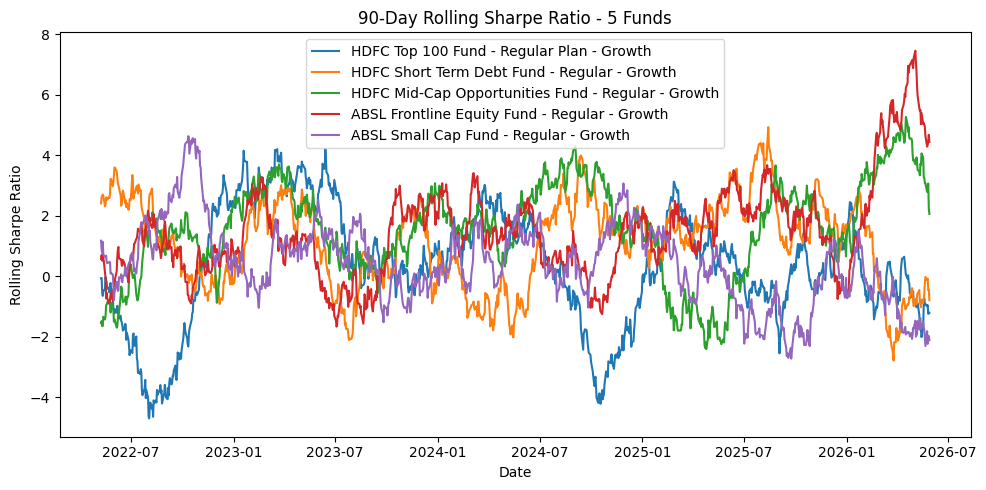

In [111]:
plt.figure(figsize=(10,5))
for code in five_funds:
    x = sharpe_plot[sharpe_plot['amfi_code'] == code]
    plt.plot(x['date'], x['rolling_sharpe'], label=x['scheme_name'].iloc[0])

plt.title('90-Day Rolling Sharpe Ratio - 5 Funds')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.legend()
plt.tight_layout()
plt.savefig('rolling_sharpe_chart.png', dpi=300)
plt.show()

In [112]:
# Investor Cohort Analysis
import pandas as pd
import numpy as np

In [113]:
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")


In [114]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [115]:
transactions.shape

(32778, 13)

In [116]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [117]:
transactions.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  object 
 1   transaction_date    32778 non-null  object 
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  object 
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  object 
 6   city                32778 non-null  object 
 7   city_tier           32778 non-null  object 
 8   age_group           32778 non-null  object 
 9   gender              32778 non-null  object 
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  object 
 12  kyc_status          32778 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 3.3+ MB


In [118]:
transactions["transaction_date"]=pd.to_datetime(transactions['transaction_date'])

In [119]:
transactions['transaction_type'].value_counts()

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [120]:
# Find each investor's first transaction.
# For every investor, we find their earliest transaction date
first_txn = (transactions.groupby('investor_id')['transaction_date'].min().reset_index())
first_txn

,investor_id,transaction_date
0,INV000001,2024-11-04
1,INV000002,2024-03-29
2,INV000003,2024-07-16
3,INV000004,2024-03-16
4,INV000005,2024-04-27
...,...,...
4995,INV004996,2024-03-04
4996,INV004997,2024-01-16
4997,INV004998,2024-01-05
4998,INV004999,2024-01-19


In [121]:
# Create the cohort year
first_txn['cohort_year']=(first_txn['transaction_date'].dt.year) # Now extract the year
first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [122]:
# Check how many investors are in each cohort
first_txn['cohort_year'].value_counts()

cohort_year
2024    4803
2025     197
Name: count, dtype: int64

In [123]:
# Add the cohort information back to the transaction data
transactions=transactions.merge(
    first_txn[["investor_id","cohort_year"]],
    on="investor_id",
    how="left"
)


In [124]:
transactions[['investor_id', 'transaction_date', 'cohort_year']].head()

,investor_id,transaction_date,cohort_year
0,INV003054,2024-01-01,2024
1,INV002952,2024-01-01,2024
2,INV003420,2024-01-01,2024
3,INV003436,2024-01-01,2024
4,INV004691,2024-01-01,2024


In [125]:
transactions['transaction_type'].value_counts()

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [126]:
# Average SIP Amount by Cohort
sip = transactions[
    transactions['transaction_type'] == 'SIP'
] #Select only SIP transactions

In [127]:
sip.shape

(19716, 14)

In [128]:
avg_sip = (sip.groupby('cohort_year')['amount_inr'].mean().reset_index())

avg_sip

,cohort_year,amount_inr
0,2024,10996.885825
1,2025,13505.209581


In [129]:
# Calculate average SIP amount for each cohort
avg_sip = (sip.groupby('cohort_year')['amount_inr'].mean().reset_index())
avg_sip

,cohort_year,amount_inr
0,2024,10996.885825
1,2025,13505.209581


In [130]:
# Rename the column
avg_sip = avg_sip.rename(columns={'amount_inr': 'avg_sip_amount'})
avg_sip

,cohort_year,avg_sip_amount
0,2024,10996.885825
1,2025,13505.209581


In [131]:
# Calculate Total Invested by Cohort
investments = transactions[
    transactions['transaction_type'].isin(['SIP', 'Lumpsum'])] #Filter investment transactions

In [132]:
total_invested = (investments.groupby('cohort_year')['amount_inr'].sum().reset_index())
total_invested

,cohort_year,amount_inr
0,2024,2258062304
1,2025,18992635


In [133]:
total_invested=total_invested.rename(columns={"amount_inr":"total_invested"})
total_invested

,cohort_year,total_invested
0,2024,2258062304
1,2025,18992635


In [134]:
# Fund Preference by Cohort
# Count transactions by cohort and fund
fund_preference = (
    investments
    .groupby(['cohort_year', 'amfi_code'])
    .size()
    .reset_index(name='transaction_count')
)

In [135]:
fund_preference.head()

,cohort_year,amfi_code,transaction_count
0,2024,100016,711
1,2024,100025,662
2,2024,100033,632
3,2024,101206,669
4,2024,101207,733


In [136]:
# Find the most preferred fund for each cohort
preferred_fund = (
    fund_preference
    .sort_values(
        ['cohort_year', 'transaction_count'],
        ascending=[True, False]
    )
    .drop_duplicates('cohort_year')
)
preferred_fund

,cohort_year,amfi_code,transaction_count
33,2024,125498,752
62,2025,119599,11


In [137]:
# Add the fund name
preferred_fund = preferred_fund.merge(
    fund[['amfi_code', 'scheme_name']].drop_duplicates(),
    on='amfi_code',
    how='left'
)

In [138]:
preferred_fund[
    ['cohort_year', 'amfi_code', 'scheme_name', 'transaction_count']
]

,cohort_year,amfi_code,scheme_name,transaction_count
0,2024,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,752
1,2025,119599,SBI Small Cap Fund - Direct Plan - Growth,11


In [139]:
# Combine everything
cohort_analysis = (
    avg_sip
    .merge(total_invested, on='cohort_year')
    .merge(
        preferred_fund[
            ['cohort_year', 'amfi_code', 'scheme_name']
        ],
        on='cohort_year',
        how='left'
    )
)

In [140]:
cohort_analysis

,cohort_year,avg_sip_amount,total_invested,amfi_code,scheme_name
0,2024,10996.885825,2258062304,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth
1,2025,13505.209581,18992635,119599,SBI Small Cap Fund - Direct Plan - Growth


In [141]:
cohort_analysis.to_csv('cohort_analysis.csv',index=False)

In [142]:
# Task 4 :SIP continuation analysis
# -------------------------------------

sip = transactions[transactions['transaction_type'] == 'SIP']

In [143]:
sip.shape

(19716, 14)

In [144]:
sip.dtypes

investor_id                   object
transaction_date      datetime64[ns]
amfi_code                      int64
transaction_type              object
amount_inr                     int64
state                         object
city                          object
city_tier                     object
age_group                     object
gender                        object
annual_income_lakh           float64
payment_mode                  object
kyc_status                    object
cohort_year                    int32
dtype: object

In [145]:
sip=sip.sort_values(['investor_id','transaction_date'])

In [146]:
# Calculate the gap between SIP transactions
sip['gap_days'] = (
    sip.groupby('investor_id')['transaction_date']
    .diff()
    .dt.days
)

In [147]:
sip[['investor_id', 'transaction_date', 'gap_days']].head(20)

,investor_id,transaction_date,gap_days
19621,INV000001,2024-11-04,NaN
24448,INV000001,2025-01-19,76.0
5650,INV000002,2024-03-29,NaN
16803,INV000002,2024-09-21,176.0
31881,INV000002,2025-05-17,238.0
12652,INV000003,2024-07-16,NaN
27622,INV000003,2025-03-11,238.0
4773,INV000004,2024-03-16,NaN
6418,INV000004,2024-04-11,26.0
8271,INV000004,2024-05-09,28.0


In [148]:
sip_counts = (sip.groupby('investor_id').size().reset_index(name='sip_count'))# Count SIP transactions per investor
sip_counts.head()

,investor_id,sip_count
0,INV000001,2
1,INV000002,3
2,INV000003,2
3,INV000004,6
4,INV000005,3


In [149]:
eligible = sip_counts[sip_counts['sip_count'] >= 6] #Keep investors with 6+ SIP transactions
eligible.shape

(1362, 2)

In [150]:
sip_continuity = (
    sip[sip['investor_id'].isin(eligible['investor_id'])]
    .groupby('investor_id')
    .agg(
        SIP_Count=('gap_days', 'count'),
        Average_Gap_Days=('gap_days', 'mean'),
        Maximum_Gap_Days=('gap_days', 'max')
    )
    .reset_index()
)
sip_continuity.head()

,investor_id,SIP_Count,Average_Gap_Days,Maximum_Gap_Days
0,INV000004,5,85.400000,265.0
1,INV000008,5,70.400000,165.0
2,INV000010,5,64.800000,139.0
3,INV000011,6,40.166667,125.0
4,INV000012,7,57.000000,132.0


In [151]:
sip_continuity['Risk_Status'] = np.where(
    sip_continuity['Average_Gap_Days'] > 35,
    'At-Risk',
    'Regular'
)
sip_continuity.head()

,investor_id,SIP_Count,Average_Gap_Days,Maximum_Gap_Days,Risk_Status
0,INV000004,5,85.400000,265.0,At-Risk
1,INV000008,5,70.400000,165.0,At-Risk
2,INV000010,5,64.800000,139.0,At-Risk
3,INV000011,6,40.166667,125.0,At-Risk
4,INV000012,7,57.000000,132.0,At-Risk


In [152]:
sip_continuity['SIP_Transaction_Count'] = (sip_continuity['SIP_Count'] + 1) #Because you have 6 SIP transactions, but only 5 gaps.

In [153]:
sip_continuity = sip_continuity.drop(
    columns='SIP_Count'
)
sip_continuity.head()

,investor_id,Average_Gap_Days,Maximum_Gap_Days,Risk_Status,SIP_Transaction_Count
0,INV000004,85.400000,265.0,At-Risk,6
1,INV000008,70.400000,165.0,At-Risk,6
2,INV000010,64.800000,139.0,At-Risk,6
3,INV000011,40.166667,125.0,At-Risk,7
4,INV000012,57.000000,132.0,At-Risk,8


In [154]:
sip_continuity.to_csv('sip_continuity.csv',index=False)

In [155]:
fund.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [156]:
# Task 5:Simple fund recommendations
scheme_performance=pd.read_csv("../data/raw/07_scheme_performance.csv")
scheme_performance['risk_grade'].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [157]:
risk_map = {
    'Low': ['Low'],
    'Moderate': ['Moderate', 'Moderately High'],
    'High': ['High', 'Very High']
}

In [158]:
def recommend_funds(risk_appetite):
    grades = risk_map[risk_appetite] #tell Python which risk grades to use

    result = scheme_performance[
        scheme_performance['risk_grade'].isin(grades) #From scheme_performance, keep only the funds whose risk_grade is in our selected grades.
    ]

    return result.sort_values(      #Arrange the funds from highest Sharpe ratio to lowest.
        'sharpe_ratio',
        ascending=False
    ).head(3)  #take only 3

In [159]:
recommend_funds('Moderate')

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,1.03,1.03,1.27,14.0,-26.59,41553,0.80,3,Moderate


In [160]:
recommend_funds("Moderate")[["amfi_code","scheme_name","risk_grade","sharpe_ratio"]]


,amfi_code,scheme_name,risk_grade,sharpe_ratio
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03


In [161]:
recommend_funds('High')[
    ['amfi_code', 'scheme_name', 'risk_grade', 'sharpe_ratio']
]

,amfi_code,scheme_name,risk_grade,sharpe_ratio
21,120842,Kotak Emerging Equity Fund - Regular - Growth,High,0.96
12,120505,ICICI Pru Midcap Fund - Regular - Growth,High,0.95
2,119598,SBI Small Cap Fund - Regular Plan - Growth,Very High,0.94


In [162]:
recommend_funds('Low')[
    ['amfi_code', 'scheme_name', 'risk_grade', 'sharpe_ratio']
]

,amfi_code,scheme_name,risk_grade,sharpe_ratio
14,120507,ICICI Pru Liquid Fund - Regular - Growth,Low,7.68
23,120844,Kotak Liquid Fund - Regular - Growth,Low,6.18
30,101208,ABSL Liquid Fund - Regular - Growth,Low,5.14


In [163]:
#then we will put the function into recommender.py 

In [164]:
# Task 6 — Sector Concentration Analysis
# --------------------------------------------
portfolio_holdings =pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [165]:
portfolio_holdings[["amfi_code","sector","weight_pct"]].head()

,amfi_code,sector,weight_pct
0,119551,Utilities,13.85
1,119551,Banking,11.19
2,119551,Diversified,9.90
3,119551,Pharma,4.76
4,119551,Paints,10.25


In [166]:
portfolio_holdings[["sector","weight_pct"]].isna().sum()

sector        0
weight_pct    0
dtype: int64

In [167]:
# Convert percentage into decimal
portfolio_holdings["weight"]=(portfolio_holdings["weight_pct"]/100) # The HHI calculation need decimal format

In [168]:
portfolio_holdings[["amfi_code","sector","weight_pct","weight"]].head()

,amfi_code,sector,weight_pct,weight
0,119551,Utilities,13.85,0.1385
1,119551,Banking,11.19,0.1119
2,119551,Diversified,9.90,0.0990
3,119551,Pharma,4.76,0.0476
4,119551,Paints,10.25,0.1025


In [169]:
# Calculate HHI for each fund
sector_hhi = portfolio_holdings.groupby("amfi_code")["weight"].apply(lambda x:(x**2).sum()).reset_index(name="HHI")
sector_hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [170]:
sector_hhi=sector_hhi.merge(fund[["amfi_code","scheme_name"]].drop_duplicates(),on="amfi_code",how="left") #add the fund name
sector_hhi

,amfi_code,HHI,scheme_name
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
5,102886,0.114693,UTI Mid Cap Fund - Regular - Growth
6,102887,0.129805,UTI Flexi Cap Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth
8,118633,0.121461,Nippon India Large Cap Fund - Direct - Growth
9,118634,0.108358,Nippon India Small Cap Fund - Regular - Growth


In [172]:
sector_hhi=sector_hhi[["amfi_code","scheme_name","HHI"]] #Put the columns in a clean order
sector_hhi.head(10)

,amfi_code,scheme_name,HHI
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.139534
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.147592
2,101206,ABSL Frontline Equity Fund - Regular - Growth,0.129332
3,101207,ABSL Small Cap Fund - Regular - Growth,0.200700
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.174709
5,102886,UTI Mid Cap Fund - Regular - Growth,0.114693
6,102887,UTI Flexi Cap Fund - Regular - Growth,0.129805
7,118632,Nippon India Large Cap Fund - Regular - Growth,0.168298
8,118633,Nippon India Large Cap Fund - Direct - Growth,0.121461
9,118634,Nippon India Small Cap Fund - Regular - Growth,0.108358


In [174]:
# the most concentrated funds
sector_hhi=sector_hhi.sort_values(["HHI"],ascending=False)
sector_hhi.head(10)

,amfi_code,scheme_name,HHI
11,119092,Axis Bluechip Fund - Regular - Growth,0.206448
3,101207,ABSL Small Cap Fund - Regular - Growth,0.200700
18,119599,SBI Small Cap Fund - Direct Plan - Growth,0.174751
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.174709
7,118632,Nippon India Large Cap Fund - Regular - Growth,0.168298
29,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,0.167930
21,120505,ICICI Pru Midcap Fund - Regular - Growth,0.157570
22,120506,ICICI Pru Value Discovery Fund - Regular - Growth,0.153794
27,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.152414
23,120841,Kotak Bluechip Fund - Regular - Growth,0.149680


In [ ]:
#the most diversified funds
sector_hhi=sector_hhi.sort_values(["HHI"],ascending=True)
sector_hhi.head(10)

,amfi_code,scheme_name,HHI
17,119598,SBI Small Cap Fund - Regular Plan - Growth,0.107349
16,119552,SBI Bluechip Fund - Direct Plan - Growth,0.108011
9,118634,Nippon India Small Cap Fund - Regular - Growth,0.108358
20,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.108674
14,119095,Axis Small Cap Fund - Regular - Growth,0.109605
5,102886,UTI Mid Cap Fund - Regular - Growth,0.114693
33,149324,DSP Small Cap Fund - Regular - Growth,0.118677
15,119551,SBI Bluechip Fund - Regular Plan - Growth,0.118716
8,118633,Nippon India Large Cap Fund - Direct - Growth,0.121461
24,120842,Kotak Emerging Equity Fund - Regular - Growth,0.127439


In [175]:
sector_hhi=sector_hhi.to_csv("sector_hhi.csv",index=False)

# Advanced Analytics Summary

## Key Insights

### 1. Fund Risk and VaR
The VaR and CVaR analysis identified funds with higher downside risk based on their historical daily returns. Funds with higher VaR values are more exposed to potential losses during adverse market conditions, while CVaR highlights the expected severity of losses beyond the VaR threshold.

### 2. Fund Risk-Adjusted Performance
The 90-day rolling Sharpe ratio was calculated for selected funds to evaluate risk-adjusted performance over time. Funds with consistently higher Sharpe ratios generated better returns relative to their volatility, making them more attractive from a risk-adjusted perspective.

### 3. Investor Cohort Analysis
Investors were grouped according to their first transaction year, particularly the 2024 and 2025 cohorts. The analysis compared average SIP investment, total invested amount, and fund preferences to understand differences in investment behaviour between newer and earlier investor cohorts.

### 4. SIP Continuation and At-Risk Investors
Investors with at least six SIP transactions were analysed based on the average gap between consecutive SIP payments. Investors with an average gap greater than 35 days were classified as **At-Risk**, indicating possible irregularity or reduced SIP continuation.

### 5. Sector Concentration and Fund Recommendations
Sector-level HHI was calculated for equity funds using sector portfolio weights. A higher HHI indicates greater concentration in fewer sectors, while a lower HHI indicates better diversification. In addition, a simple recommendation model ranked funds by Sharpe ratio within the investor's risk appetite and returned the top three suitable funds.